In [9]:
import os
import subprocess
import signal
import re
import csv
import time
import threading
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline 

# --- UI Widgets ---
slam_dropdown = widgets.Dropdown(options=['cartographer', 'rtabmap', 'orb_slam3'], value='orb_slam3', description='SLAM:')
perception_dropdown = widgets.Dropdown(options=['sam2', 'deeplabv3'], value='sam2', description='Perception:')

run_button = widgets.Button(description="1. Run Simulation", button_style='primary')
stop_button = widgets.Button(description="2. Stop & Evaluate", button_style='danger', disabled=True)
output_area = widgets.Output()

display(widgets.HBox([slam_dropdown, perception_dropdown]), widgets.HBox([run_button, stop_button]), output_area)

current_process = None
current_backend = None
current_perception = None

def stream_logs(process):
    # This is the 100% reliable way to force text to the screen from a background thread!
    for line in iter(process.stdout.readline, b''):
        if line:
            decoded = line.decode('utf-8', errors='ignore').strip()
            if "xterm" not in decoded and "libGL" not in decoded and "MESA" not in decoded:
                output_area.append_stdout(f"[ROS2] {decoded}\n")

def on_run_click(b):
    global current_process, current_backend, current_perception
    output_area.clear_output()
    
    current_backend = slam_dropdown.value
    current_perception = perception_dropdown.value
    
    run_button.disabled = True
    stop_button.disabled = False
    
    # Ensure Gazebo and Xterm know how to access the screen!
    display_var = os.environ.get('DISPLAY', ':0')
    os.environ['DISPLAY'] = display_var
    
    output_area.append_stdout(f"============================================================\n")
    output_area.append_stdout(f"Starting Gazebo Simulation: {current_backend} + {current_perception}\n")
    output_area.append_stdout(f"Using DISPLAY={display_var}\n")
    output_area.append_stdout(f"============================================================\n\n")
    output_area.append_stdout(">>> Simulation is launching! Gazebo will open in a new window.\n")
    output_area.append_stdout(">>> Open a terminal inside your Docker container and run:\n")
    output_area.append_stdout(">>>    ros2 run teleop_twist_keyboard teleop_twist_keyboard\n")
    output_area.append_stdout(">>> Drive the robot around to map the house.\n")
    output_area.append_stdout(">>> When you are done, click the red 'Stop & Evaluate' button!\n\n")

    launch_file = f"eval_{current_backend.replace('_', '')}.launch.py"
    
    # We source the main ROS 2 Humble setup file to guarantee the 'ros2' command is found
    cmd_run = f"export PYTHONUNBUFFERED=1 && source /opt/ros/humble/setup.bash && source /ros2_ws/install/setup.bash && ros2 launch slam_fusion {launch_file} run_mode:=simulation perception_model:={current_perception}"
    
    current_process = subprocess.Popen(
        cmd_run, shell=True, executable="/bin/bash", 
        start_new_session=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT
    )
    
    threading.Thread(target=stream_logs, args=(current_process,), daemon=True).start()

def stop_and_evaluate_thread():
    global current_process
    
    output_area.append_stdout(f"\n>>> Stopping simulation and saving trajectories (Waiting 15 seconds)...\n")

    os.killpg(current_process.pid, signal.SIGINT)
    time.sleep(15)
    
    try:
        os.killpg(current_process.pid, signal.SIGKILL)
    except Exception:
        pass
        
    current_process.wait()
    current_process = None
    
    actual_backend = current_backend.replace("_", "")
    estimated_traj_file = f"/ros2_ws/{actual_backend}_{current_perception}_estimate.txt"
    groundtruth_file = "/ros2_ws/gazebo_groundtruth.txt"
    
    output_area.append_stdout(f"\n============================================================\n")
    output_area.append_stdout(f"Evaluating Trajectory: {estimated_traj_file}\n")
    output_area.append_stdout(f"============================================================\n\n")
    
    cmd_eval = f"/ros2_ws/src/slam_fusion/scripts/evaluate_trajectory.sh {estimated_traj_file} {groundtruth_file}"
    eval_process = subprocess.run(cmd_eval, shell=True, executable="/bin/bash", stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    
    output_text = eval_process.stdout
    output_area.append_stdout(output_text + "\n")
    
    match = re.search(r"rmse\s+([0-9.]+)", output_text)
    if match:
        rmse = float(match.group(1))
        output_area.append_stdout(f"\n>>> Final RMSE: {rmse} m\n")
        
        csv_path = f"/ros2_ws/src/results/simulation_trials.csv"
        with open(csv_path, "a", newline="") as f:
            writer = csv.writer(f)
            writer.writerow([current_backend, current_perception, rmse])
        output_area.append_stdout(f">>> Successfully saved results to {csv_path}!\n")
    else:
        output_area.append_stdout("\n>>> ERROR: Could not find RMSE! Check if the trajectory file was created.\n")
            
    run_button.disabled = False
    stop_button.disabled = True

def on_stop_click(b):
    if current_process is None: return
    stop_button.disabled = True
    threading.Thread(target=stop_and_evaluate_thread, daemon=True).start()

run_button.on_click(on_run_click)
stop_button.on_click(on_stop_click)

Output()

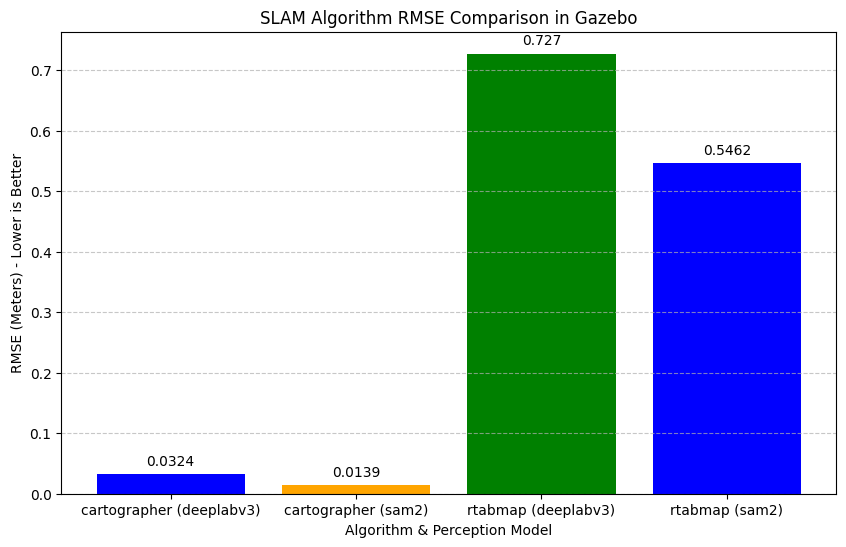

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the results you extracted
csv_path = "/ros2_ws/src/results/simulation_trials.csv"
df = pd.read_csv(csv_path, names=['Algorithm', 'Perception', 'RMSE'])

# 2. Group the data to see the comparison
# If you ran multiple trials of the same algorithm, this takes the average
summary = df.groupby(['Algorithm', 'Perception']).mean().reset_index()

# 3. Plot the Bar Chart
plt.figure(figsize=(10, 6))
bars = plt.bar(summary['Algorithm'] + " (" + summary['Perception'] + ")", summary['RMSE'], color=['blue', 'orange', 'green'])

# Add labels and title
plt.title('SLAM Algorithm RMSE Comparison in Gazebo')
plt.ylabel('RMSE (Meters) - Lower is Better')
plt.xlabel('Algorithm & Perception Model')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show exact numbers on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom')

plt.show()